# DST-index 

##### It is used to identify a geomagnetic storm by measuring its intensity.
##### DST ---> Disturbance Storm Time
##### Unit ---> NanoTesla (nT)
<br>
It quantifies the strength of the Earth's ring current.

<b>Ring Current of the Earth</b><br>
- Dougnut shaped
- A ring of trapped charged particles like high energy ions(protons and oxygen ions) and electrons flows around the Earth.
- It produced magnetic field opposite to Earth's natural field.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates

Reading and naming the columns of Dst data using Pandas

In [3]:
dir = r'C:\Users\eleen\OneDrive\Desktop\Event_Based_Project\Dst_Jan2026.txt'

df = pd.read_csv(dir,skiprows=6,header= None,sep=r'\s+')
df.columns = ['DAY','Hour 1','Hour 2','Hour 3','Hour 4','Hour 5','Hour 6','Hour 7','Hour 8','Hour 9','Hour 10','Hour 11','Hour 12','Hour 13','Hour 14','Hour 15','Hour 16','Hour 17','Hour 18','Hour 19','Hour 20','Hour 21','Hour 22','Hour 23','Hour 24']

print(df.columns)

Index(['DAY', 'Hour 1', 'Hour 2', 'Hour 3', 'Hour 4', 'Hour 5', 'Hour 6',
       'Hour 7', 'Hour 8', 'Hour 9', 'Hour 10', 'Hour 11', 'Hour 12',
       'Hour 13', 'Hour 14', 'Hour 15', 'Hour 16', 'Hour 17', 'Hour 18',
       'Hour 19', 'Hour 20', 'Hour 21', 'Hour 22', 'Hour 23', 'Hour 24'],
      dtype='str')


First five rows of 24 hours

In [4]:
print(df.head())

   DAY  Hour 1  Hour 2  Hour 3  Hour 4  Hour 5  Hour 6  Hour 7  Hour 8  \
0    1       2       4       2       4      14      19      20      18   
1    2       0       3       4       5       1      -2       2       5   
2    3     -26     -23     -20     -21     -19     -18     -11      -7   
3    4      -1      -1      -1       1       2       1       3       6   
4    5       5       4       6       0     -13     -15     -22     -29   

   Hour 9  ...  Hour 15  Hour 16  Hour 17  Hour 18  Hour 19  Hour 20  Hour 21  \
0       5  ...       -1       -4       -8      -12       -8       -6       -9   
1      -2  ...      -15      -13       -4       -6      -14      -17      -14   
2      -5  ...      -18      -21      -27      -26      -19      -10       -6   
3       9  ...        9       10       11        8       10       10        5   
4     -30  ...      -28      -22      -18      -14      -15       -9       -5   

   Hour 22  Hour 23  Hour 24  
0      -10      -17       -8  
1     

 - Convert the raw hourly Dst values into a single time series DataFrame.<br>
 - Each row in the original dataframe contains one day and 24 hourly Dst readings.

In [5]:
times = []
dst_values = []

for index , row in df.iterrows():     # iterrows --> return tuple of(index,row_series)
    # Extracted the day number from the current row.
    day = int(row['DAY'])

    # Created a datetime for each hour of that day and collect the matching Dst value.
    for h in range(24):
        times.append(datetime(2026, 1, day, h))  # for times list

        dst_values.append(row[f'Hour {h+1}'])    # for dst_values list

# Created a  DataFrame with datetime and Dst value for every hour.
dst_df = pd.DataFrame({'Time': times,'Dst': dst_values})

print(dst_df.to_string())

                   Time  Dst
0   2026-01-01 00:00:00    2
1   2026-01-01 01:00:00    4
2   2026-01-01 02:00:00    2
3   2026-01-01 03:00:00    4
4   2026-01-01 04:00:00   14
5   2026-01-01 05:00:00   19
6   2026-01-01 06:00:00   20
7   2026-01-01 07:00:00   18
8   2026-01-01 08:00:00    5
9   2026-01-01 09:00:00    1
10  2026-01-01 10:00:00    4
11  2026-01-01 11:00:00    8
12  2026-01-01 12:00:00    4
13  2026-01-01 13:00:00    3
14  2026-01-01 14:00:00   -1
15  2026-01-01 15:00:00   -4
16  2026-01-01 16:00:00   -8
17  2026-01-01 17:00:00  -12
18  2026-01-01 18:00:00   -8
19  2026-01-01 19:00:00   -6
20  2026-01-01 20:00:00   -9
21  2026-01-01 21:00:00  -10
22  2026-01-01 22:00:00  -17
23  2026-01-01 23:00:00   -8
24  2026-01-02 00:00:00    0
25  2026-01-02 01:00:00    3
26  2026-01-02 02:00:00    4
27  2026-01-02 03:00:00    5
28  2026-01-02 04:00:00    1
29  2026-01-02 05:00:00   -2
30  2026-01-02 06:00:00    2
31  2026-01-02 07:00:00    5
32  2026-01-02 08:00:00   -2
33  2026-01-02

Plotting Dst index of one month (January 2026)

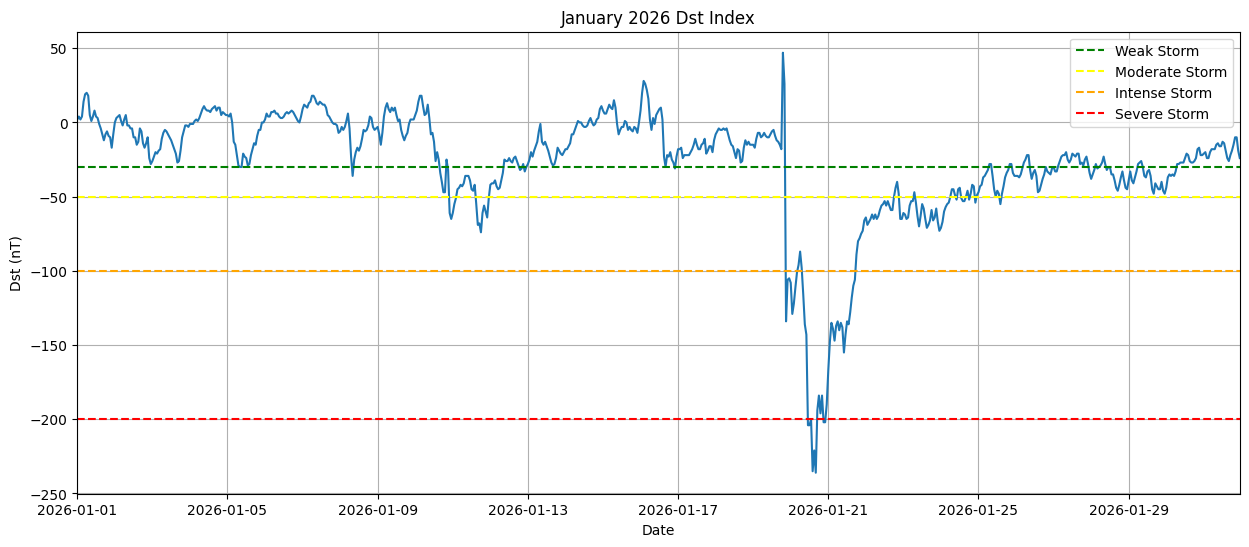

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(dst_df['Time'],
         dst_df['Dst'],
         linewidth=1.5)

plt.axhline(-30,linestyle='--',color = 'green',label='Weak Storm')
plt.axhline(-50,linestyle='--',color = 'yellow',label='Moderate Storm')
plt.axhline(-100,linestyle='--',color = 'orange',label='Intense Storm')
plt.axhline(-200,linestyle='--',color = 'red',label='Severe Storm')

plt.xlim(dst_df['Time'].min(),
         dst_df['Time'].max())

plt.xlabel('Date')
plt.ylabel('Dst (nT)')
plt.title('January 2026 Dst Index')

plt.grid(True)
plt.legend()
# plt.savefig('January_2026_Dst_with_date.pdf',dpi=1000)
plt.savefig("January_2026_Dst_with_date.png", dpi=300)
plt.show()

Found minimum Dst

In [7]:
min_row = dst_df.loc[dst_df['Dst'].idxmin()]  # idxmin() --> returns index where Dst is minimum

print(min_row)

Time    2026-01-20 16:00:00
Dst                    -236
Name: 472, dtype: object


Plotting Dst index of one month (January 2026) with minimum Dst

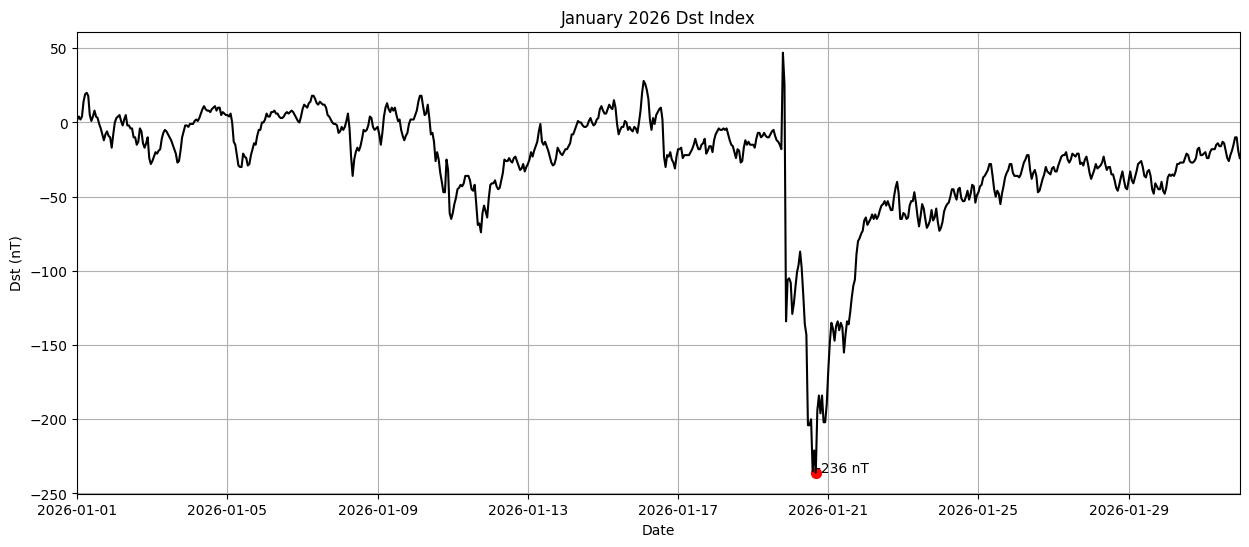

In [8]:
min_row = dst_df.loc[dst_df['Dst'].idxmin()]

plt.figure(figsize=(15,6))

plt.plot(dst_df['Time'],
         dst_df['Dst'],color = 'black')

plt.scatter(min_row['Time'],
            min_row['Dst'],
            s=50,c='red')

plt.annotate(
    f"{min_row['Dst']} nT",
    (min_row['Time'], min_row['Dst'])
)

plt.xlim(dst_df['Time'].min(),
         dst_df['Time'].max())

plt.xlabel('Date')
plt.ylabel('Dst (nT)')
plt.title('January 2026 Dst Index')

plt.grid(True)
# plt.savefig('January_2026_Dst_with_min.pdf',dpi=1000)
plt.savefig("January_2026_Dst_with_min.png", dpi=300)
plt.show()

- Geomagnetic Storm Classification
   * Weak Storm --> -50 nT to -30 nT
   * Moderate Storm --> -100 nT to -50 nT
   * Intense Storm --> -200 nT to -100 nT
   * Severe Storm --> Below -200 nT

<b>Weak Strom</b>

In [9]:
storm = dst_df[dst_df['Dst'] < -30]

print(storm.head())

                   Time  Dst
176 2026-01-08 08:00:00  -36
232 2026-01-10 16:00:00  -34
233 2026-01-10 17:00:00  -40
234 2026-01-10 18:00:00  -47
235 2026-01-10 19:00:00  -47


<b>Moderate Strom</b>

In [10]:
storm = dst_df[dst_df['Dst'] < -50]

print(storm.head())

                   Time  Dst
238 2026-01-10 22:00:00  -61
239 2026-01-10 23:00:00  -65
240 2026-01-11 00:00:00  -61
241 2026-01-11 01:00:00  -55
242 2026-01-11 02:00:00  -51


<b>Intense Strom</b>

In [11]:
storm = dst_df[dst_df['Dst'] < -100]

print(storm.head())

                   Time  Dst
453 2026-01-19 21:00:00 -134
454 2026-01-19 22:00:00 -106
455 2026-01-19 23:00:00 -105
456 2026-01-20 00:00:00 -108
457 2026-01-20 01:00:00 -129


<b>Severe Strom</b>

In [12]:
storm = dst_df[dst_df['Dst'] < -200]

print(storm.head())

                   Time  Dst
467 2026-01-20 11:00:00 -204
468 2026-01-20 12:00:00 -204
470 2026-01-20 14:00:00 -235
471 2026-01-20 15:00:00 -221
472 2026-01-20 16:00:00 -236


Plotting Dst index of 31 days (January 2026) with minimum Dst

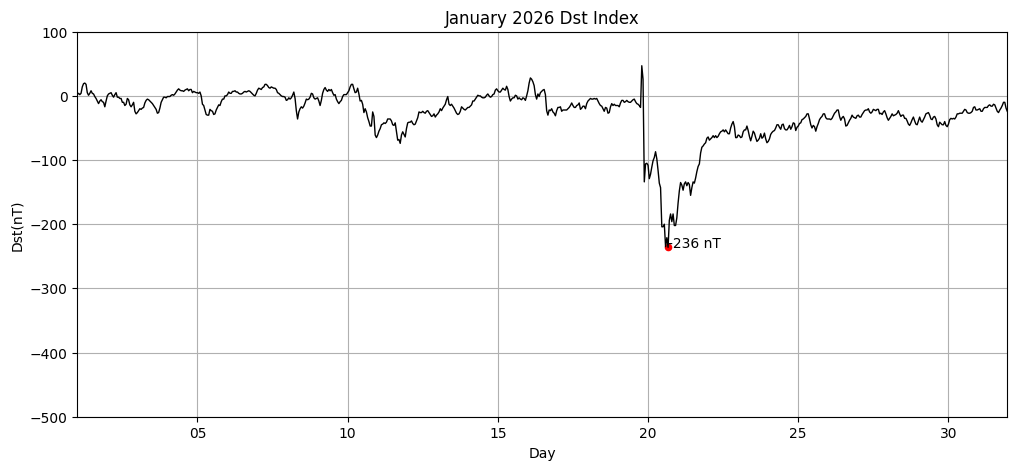

In [13]:
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(dst_df['Time'], dst_df['Dst'], 'k-', linewidth=1)

plt.scatter(min_row['Time'],min_row['Dst'],s=20,c='red')

ax.set_ylim(-500, 100)


# Major ticks every 5 days
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

ax.annotate(
    f"{min_row['Dst']} nT",
    (min_row['Time'], min_row['Dst']))

ax.set_xlim(dst_df['Time'].min(),
         dst_df['Time'].max())

ax.set_xlabel('Day')
ax.set_ylabel('Dst(nT)')
ax.set_title('January 2026 Dst Index')

ax.grid(True)
# plt.savefig('January_2026_Dst_with_day.pdf',dpi=1000)
plt.savefig("January_2026_Dst_with_day.png", dpi=300)
plt.show()

- ANALYSIS
    * Quiet Period : 16_18 January 2026
    * Storm commencement : 19 January 2026
    * Storm Peak : 20 January 2026
    * Minimum Dst : -236 nT
    * Recovory Phase : 21_26 January 2026

<b>The Geomagnetic Storm ocurred during 19_24 January 2026, with its maximum intensity on 20 January 2026</b>